# Chapter 10: Any to Any Models

In [ ]:
# Here some installs that we will be using in multiple parts of the chapter
!pip install torch Pillow requests
!pip install transformers==5.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 26.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# Very important to be logged in!
from huggingface_hub import login
login()

## 10.1 Unified Vocabulary Models
### 10.1.1 Monolithic architectures

#### In Practice: Deepseek’s Janus-Pro (a transitional architecture)


In [ ]:
import torch
from PIL import Image
import requests
import io
from PIL import Image
from transformers import JanusForConditionalGeneration, JanusProcessor

In [ ]:
import torch
from PIL import Image
import requests
from transformers import JanusForConditionalGeneration, AutoProcessor

# Define the model ID
model_id = "deepseek-community/Janus-Pro-1B"

# Load the Janus Processor and Model
print(f"Loading processor from {model_id}...")
processor = AutoProcessor.from_pretrained(
    "deepseek-community/Janus-Pro-1B",
    use_fast=False,
)
print(f"Loading model from {model_id}...")
model = JanusForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

print("Model and processor loaded successfully!")

Loading processor from deepseek-community/Janus-Pro-1B...


processor_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading model from deepseek-community/Janus-Pro-1B...


model.safetensors:   0%|          | 0.00/4.15G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/964 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

Model and processor loaded successfully!


**Example 1: Text-based Question Answering**

This section demonstrates how to use the Janus-Pro model to answer text-based questions. We'll prepare a list of messages in a chat-like format, apply the processor's chat template, and then generate a response.

In [ ]:
# Define the messages for text QA
messages_text_qa = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Which planet is the largest in our solar system?",
            }
        ],
    }
]

print("--- Input for Text QA ---")
print(messages_text_qa)

# Apply chat template and tokenize inputs
inputs_text_qa = processor.apply_chat_template(
    messages_text_qa,
    add_generation_prompt=True,
    generation_mode="text",
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device, dtype=torch.bfloat16)

# Generate output
print("Generating text QA response...")
outputs_text_qa = model.generate(
    **inputs_text_qa,
    max_new_tokens=64,
    generation_mode="text",
    do_sample=False,
)

# Decode and print the response
print("\n--- Text QA Output ---")
print(processor.decode(outputs_text_qa[0], skip_special_tokens=True))

Passing `generation_config` together with generation-related arguments=({'guidance_scale', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


--- Input for Text QA ---
[{'role': 'user', 'content': [{'type': 'text', 'text': 'Which planet is the largest in our solar system?'}]}]
Generating text QA response...

--- Text QA Output ---
You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.

: Which planet is the largest in our solar system?

:I'm sorry, but I'm not able to provide information about the size of planets in our solar system. However, I can help you find information on the largest planet in our solar system.


***Example 2: Visual Question Answering***

This section showcases how to perform Visual Question Answering (VQA) with the Janus-Pro model. We'll load an image from a URL, combine it with a text question in the chat template, and generate a text-based answer about the image.

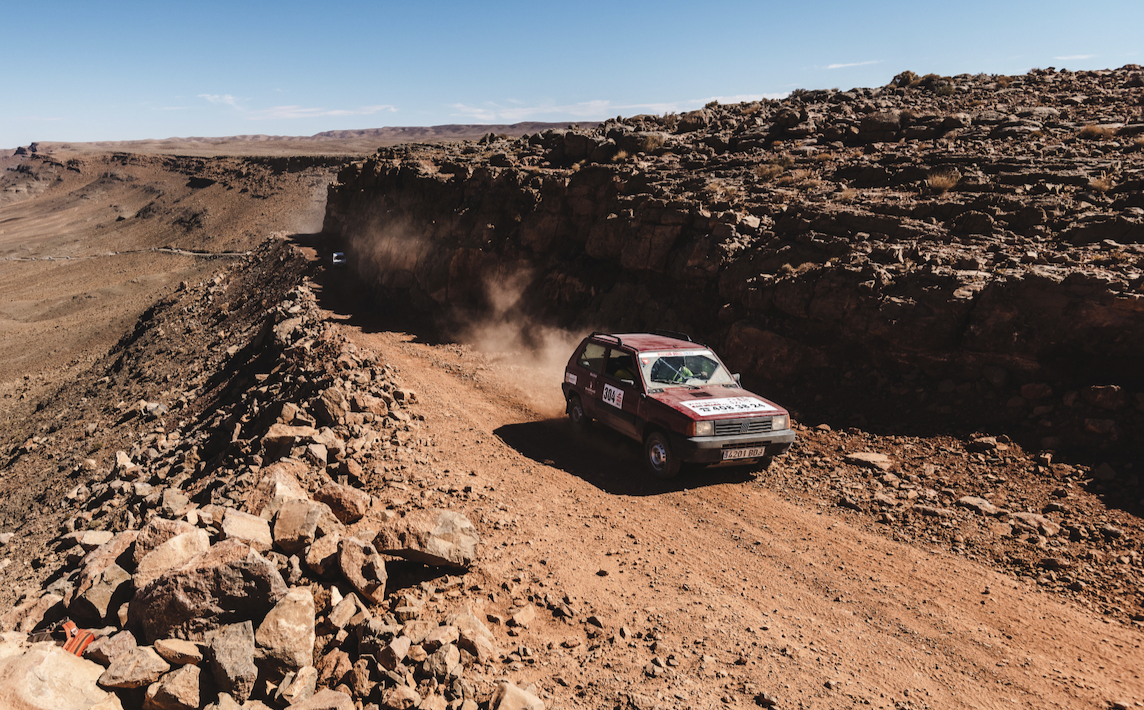

In [ ]:
# Load image
image_url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/panda.png"
image = Image.open(io.BytesIO(requests.get(image_url, timeout=30).content)).convert("RGB")
image


In [ ]:

#Messages: INLINE the PIL image for Janus
messages_visual_qa = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},   # <-- inline PIL image
            {"type": "text", "text": "What is happening in the photo?"},
        ],
    }
]

# Build inputs
inputs_visual_qa = processor.apply_chat_template(
    messages_visual_qa,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

# Move tensors to device
device = next(model.parameters()).device
inputs_visual_qa = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                    for k, v in inputs_visual_qa.items()}

# Generate + decode
outputs_visual_qa = model.generate(**inputs_visual_qa, max_new_tokens=64, do_sample=False)
print(processor.batch_decode(outputs_visual_qa, skip_special_tokens=True)[0])


You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.

: 
What is happening in the photo?

:The photo shows a car navigating a rough, rocky terrain. The car appears to be participating in an off-road rally or race, as it is surrounded by loose rocks and uneven ground.


***Example 3: Text-to-Image Generation***

This section demonstrates how to use the Janus-Pro model to generate an image from a text prompt. We'll provide a descriptive text, and the model will create a corresponding image. The generated image will be saved and displayed.

Loading weights:   0%|          | 0/964 [00:00<?, ?it/s]

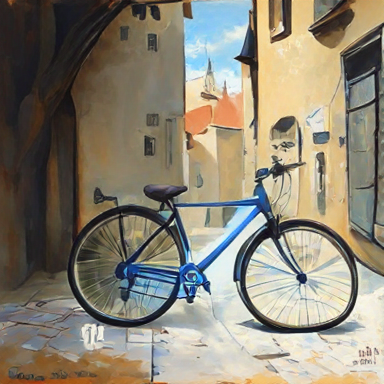

processor: JanusProcessor
pad_token: '<｜▁pad▁｜>' pad_token_id: 100002
num_image_tokens: 576
generated token range: 23 16319
saved janus_t2i_fix.png


In [ ]:
# Janus text-to-image patch for transformers 5.2
# What is going on? Why this cell is low level?
#
# In this environment, the standard Hugging Face image-generation entry point
#
#     model.generate(..., generation_mode="image")
#
# produced malformed / scrambled images for Janus.
#
# The workaround below keeps the same processor and model, but replaces only the
# fragile generation path with a small manual loop:
#
#   1) prepare the prompt with JanusProcessor in image mode
#   2) run an explicit autoregressive loop for exactly the image-token length
#   3) apply classifier-free guidance (CFG) manually
#   4) decode the image tokens with model.decode_image_tokens(...)
#   5) convert the decoded tensor to a PIL image manually
#
# It is simply a patched inference path that is more reliable on transformers 5.2.

import numpy as np
import torch
from PIL import Image
from IPython.display import display
from transformers import JanusForConditionalGeneration, JanusProcessor

MODEL_ID = "deepseek-community/Janus-Pro-1B"
PROMPT = "A painting of a bike parked in the old town of Bern."
CFG = 5.0
TEMPERATURE = 1.0
SEED = 0

device = "cuda"

# Important detail:
# use_fast=False is needed in this environment for Janus to start correctly.
processor = JanusProcessor.from_pretrained(MODEL_ID, use_fast=False)
tokenizer = processor.tokenizer

# The unconditional CFG branch is created by replacing the natural-language
# prompt tokens with PAD tokens, so a valid pad_token_id is required.
assert tokenizer.pad_token_id is not None, "pad_token_id is required for CFG"

model = JanusForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
).to(device).eval()

# Janus expects a chat-style prompt, even for text-to-image.
messages = [
    {
        "role": "user",
        "content": [{"type": "text", "text": PROMPT}],
    }
]

# Build the textual prompt the same way the official Janus chat interface does.
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)


inputs = processor(text=prompt, generation_mode="image", return_tensors="pt")
input_ids = inputs["input_ids"].to(device)

# Janus uses a fixed number of image tokens for 384x384 generation.
# For this model/config that is 576 tokens (24 x 24 latent grid).
num_image_tokens = model.config.vision_config.num_image_tokens

# Do not get scared by this patch! We added a manual classifier-free guidance (CFG) setup
# We build a 2-row batch:
#
#   row 0 = conditional prompt  -> "A painting of a bike parked in the old town of Bern."
#   row 1 = unconditional prompt -> same structure, but text replaced by PAD
#
# This lets us get both conditional and unconditional logits in one forward pass.
tokens = input_ids.repeat(2, 1)

# Preserve the control tokens at the edges and blank out only the text region.
# In practice, row 1 becomes the "empty prompt" branch used by CFG.
tokens[1, 1:-1] = tokenizer.pad_token_id

# We grab the submodules we need directly because we are bypassing the higher-level generate() helper.
lm = model.model.language_model
gen_head = model.model.generation_head

# Convert token ids to embeddings once for the initial prompt.
inputs_embeds = model.get_input_embeddings()(tokens)

# We will fill this tensor one image token at a time.
generated = torch.empty((1, num_image_tokens), dtype=torch.long, device=device)

# KV cache for autoregressive decoding.
past_key_values = None

# Separate generator so multinomial sampling is deterministic under the seed above.
gen = torch.Generator(device=device)

# Patched autoregressive image-token loop
# That makes the behavior much closer to Janus' original inference style and avoids
# the malformed-image issue seen on transformers 5.2.
with torch.inference_mode():
    for i in range(num_image_tokens):
        # Run one decoding step using the current prompt/image-token prefix.
        out = lm(
            inputs_embeds=inputs_embeds,
            past_key_values=past_key_values,
            use_cache=True,
        )
        past_key_values = out.past_key_values

        # Keep only the logits for the newest position.
        logits = gen_head(out.last_hidden_state[:, -1, :])

        # Split the batch back into:
        #   cond   = logits from the real prompt
        #   uncond = logits from the padded prompt
        cond, uncond = logits[0:1], logits[1:2]

        # Standard classifier-free guidance:
        #   guided = uncond + scale * (cond - uncond)
        #
        # Larger CFG pushes the image to follow the prompt more strongly.
        guided = uncond + CFG * (cond - uncond)

        # Sample the next image token.
        # TEMPERATURE=0 switches to greedy decoding.
        if TEMPERATURE == 0:
            next_token = guided.argmax(dim=-1)
        else:
            probs = torch.softmax(guided / TEMPERATURE, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1, generator=gen).squeeze(-1)

        # Store the sampled token in the output grid.
        generated[:, i] = next_token

        # The next step must consume this token as an image token embedding,
        # not as ordinary text-token embedding.
        #
        # We repeat it twice because the next forward pass still expects the
        # 2-row CFG batch: one row for cond, one row for uncond.
        dual = next_token.repeat_interleave(2)  # [tok, tok]

        # This Janus helper converts image token ids into the embeddings expected
        # by the multimodal decoder for the next autoregressive step.
        inputs_embeds = model.prepare_embeddings_for_image_generation(dual.unsqueeze(-1))

# Decode image tokens -> pixels
# Latest part of the patch:
# we avoid processor.postprocess(...) and instead convert the decoded tensor
# ourselves, because that path behaved more reliably in this 5.2 setup.
decoded = model.decode_image_tokens(generated)

# Some builds return BCHW, some effectively BHWC-like layouts.
# If channels are in position 1, move them to the end so PIL can consume HWC.
if decoded.ndim == 4 and decoded.shape[1] in (1, 3):
    decoded = decoded.permute(0, 2, 3, 1)

decoded = decoded.float().cpu().detach().numpy()

# Janus decode_image_tokens returns normalized image values.
# Convert from approximately [-1, 1] to [0, 1], then to uint8 [0, 255].
img = np.clip((decoded[0] + 1.0) / 2.0, 0.0, 1.0)
image = Image.fromarray((img * 255).round().astype(np.uint8))

# Save and display the final image.
image.save("janus_t2i_fix.png")
display(image)

# Small debug printout so readers can verify the assumptions of the patch.
print("processor:", type(processor).__name__)
print("pad_token:", repr(tokenizer.pad_token), "pad_token_id:", tokenizer.pad_token_id)
print("num_image_tokens:", num_image_tokens)
print("generated token range:", int(generated.min()), int(generated.max()))
print("saved janus_t2i_fix.png")

### 10.1.2 Factorized Heads
#### In Pracice: Qwen2.5-Omni (thinker talker)

In [ ]:
import os
import tempfile
from pathlib import Path

import requests
import soundfile as sf
import torch
from transformers import Qwen2_5OmniForConditionalGeneration, Qwen2_5OmniProcessor, Qwen2_5OmniConfig

model_id = "Qwen/Qwen2.5-Omni-3B"
model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
    model_id,
    dtype="auto",
    device_map="auto",
).eval()
processor = Qwen2_5OmniProcessor.from_pretrained(model_id)



config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2543 [00:00<?, ?it/s]

Qwen2_5OmniForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-Omni-3B
Key                                                | Status     |  | 
---------------------------------------------------+------------+--+-
token2wav.code2wav_dit_model.rotary_embed.inv_freq | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

In [ ]:

video_url = "https://huggingface.co/datasets/vlmbook/videos/resolve/main/StKxb6z-MHk.mp4"

tmp_path = tempfile.mktemp(suffix=".mp4")
Path(tmp_path).write_bytes(requests.get(video_url).content)



1284261

In [ ]:

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "video", "video": str(tmp_path)},
            {"type": "text", "text": "Describe what you see and hear."},
        ],
    },
]

# Prepare inputs (extract audio from video and enable audio generation)
inputs = processor.apply_chat_template(
    conversation,
    load_audio_from_video=True,
    use_audio_in_video=True,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    fps=0.5,
    padding=True,
).to(model.device)

# Generate text (Thinker) and speech (Talker)
text_ids, audio = model.generate(
    **inputs,
    use_audio_in_video=True,
    thinker_do_sample=False,
    talker_do_sample=True,
)

# Decode and save
text = processor.batch_decode(
    text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]

print(text)

wav = audio.reshape(-1).detach().cpu().numpy()
sf.write("output.wav", wav, 24000)
print("Saved speech to output.wav, go check it out")


Setting `pad_token_id` to `eos_token_id`:8292 for open-end generation.


system
You are a helpful assistant.
user
Describe what you see and hear.
assistant
The video shows a man and a woman standing in front of a wall displaying various basketball jerseys. The man is wearing a white t-shirt with the words "SNEAKER DEBT" printed on it, along with black pants and white sneakers. He is holding a microphone and appears to be interviewing the woman. The woman is wearing a white t-shirt and gray pants. The background features a wooden wall with multiple basketball jerseys hanging on it, showcasing different colors and numbers. The man asks the woman about the number of pairs of shoes she has in her collection, and she responds with a series of numbers, including "6 or 7," "20," and "40." The man then asks her again about the number of pairs of shoes in her sneaker collection, and she responds with "30 40." The video captures their interaction as they discuss the number of pairs of shoes in her collection.
Saved speech to output.wav, go check it out


## 10.3 Late Conditioning Models
### 10.3.4 Hands on: Qwen-Image-Edit, a modular diffusion editor


We will run Qwen Image Edit in two different ways: in the first cell using the prepared diffusers pipeline and in the second cell running the VLM part and generator separately

In [ ]:
from diffusers import QwenImageEditPipeline
from PIL import Image
import torch
import requests
from io import BytesIO

url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/panda.png"

pipe = QwenImageEditPipeline.from_pretrained("Qwen/Qwen-Image-Edit", torch_dtype=torch.bfloat16).to("cuda")

img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
img = img.resize((512 , 512))
out = pipe(
    image=img,
    prompt="add vegetation to the landscape",
    true_cfg_scale=4.0,
    negative_prompt=" ",
    num_inference_steps=50,
    generator=torch.manual_seed(0),
)

out.images[0].save("output.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

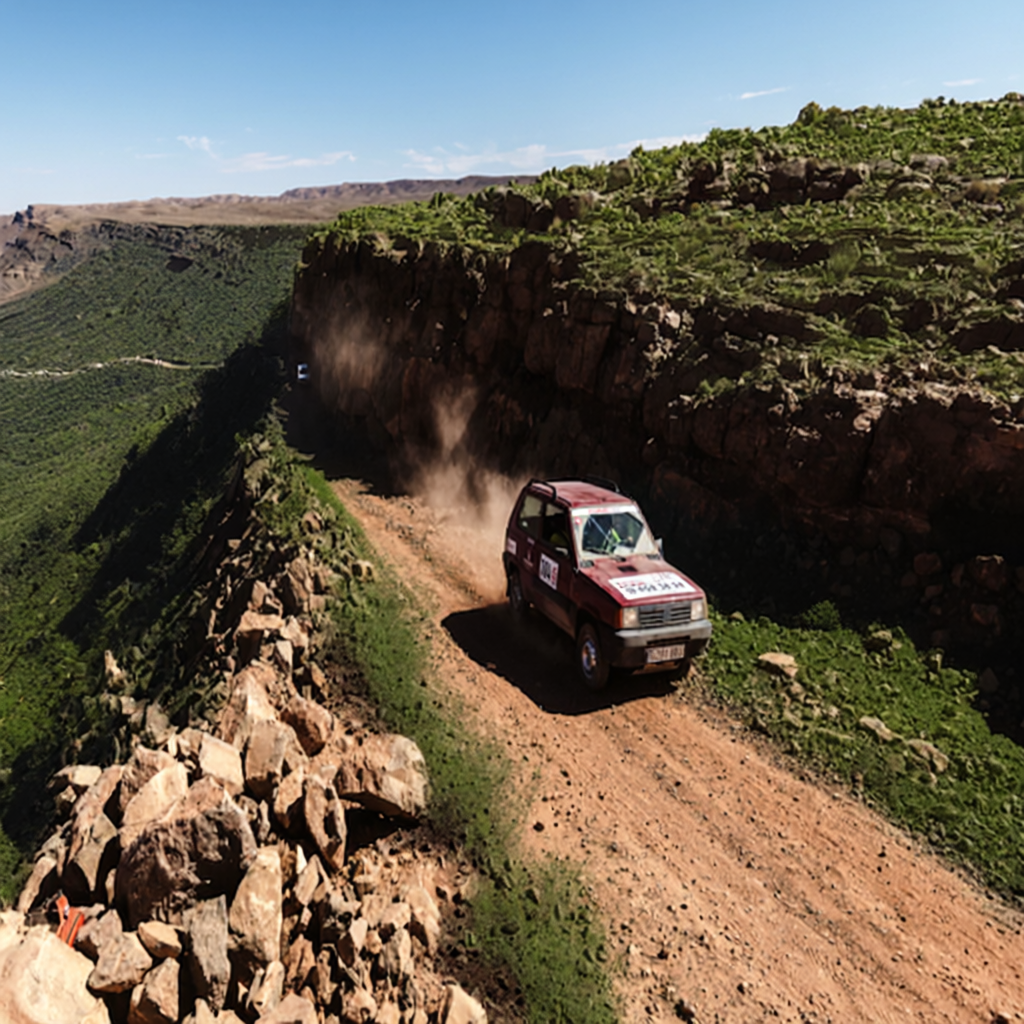

In [ ]:
out.images[0]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

prompt_embeds: <class 'torch.Tensor'> torch.Size([1, 1381, 3584]) torch.bfloat16
prompt_embeds_mask: <class 'NoneType'> None


  0%|          | 0/40 [00:00<?, ?it/s]

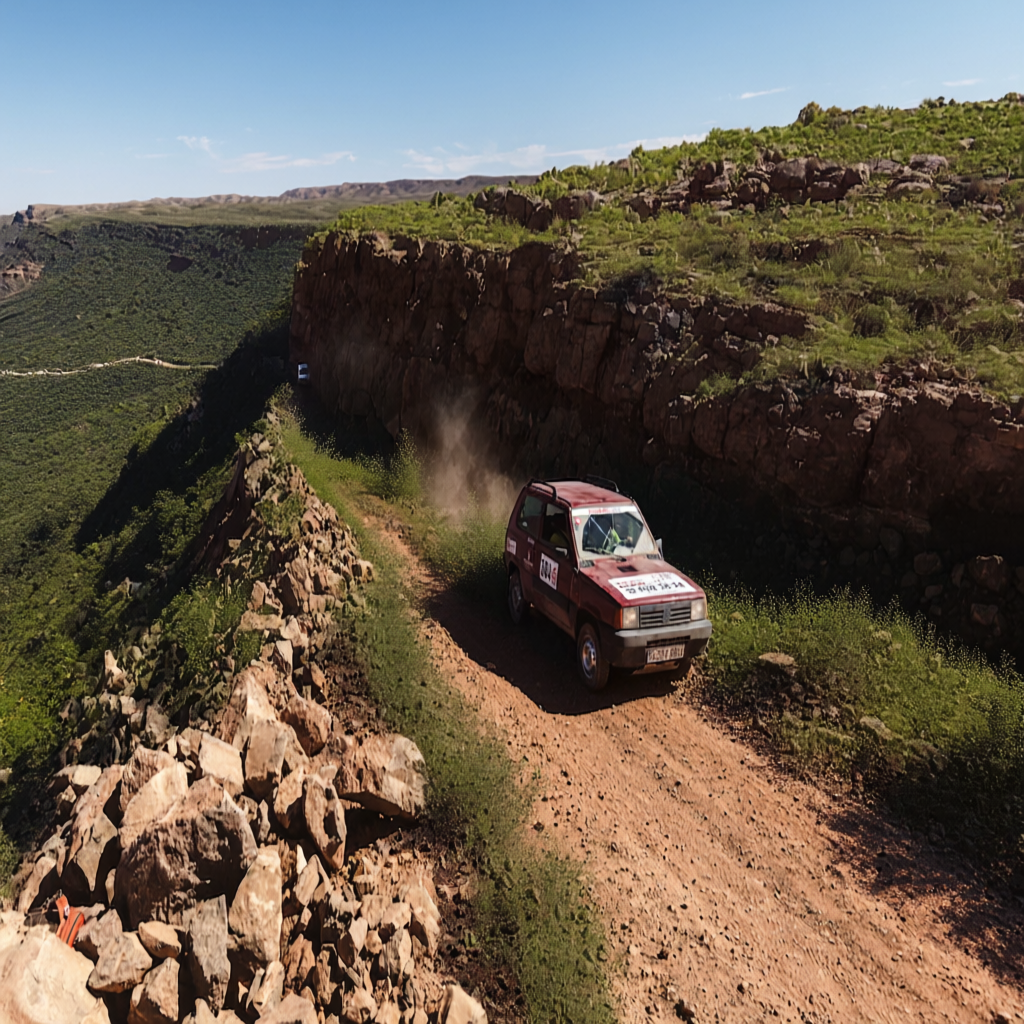

In [ ]:
import torch
import requests
from PIL import Image
from io import BytesIO
from diffusers import QwenImageEditPipeline

url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/panda.png"
img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
img = img.resize((1024 , 1024))

pipe = QwenImageEditPipeline.from_pretrained(
    "Qwen/Qwen-Image-Edit",
    torch_dtype=torch.bfloat16,
).to("cuda")

instruction = "add vegetation to the landscape"

# 1- Run from the VLM until the embeddings
prompt_embeds, prompt_embeds_mask = pipe.encode_prompt(
    prompt=instruction,
    image=img,
)

print("prompt_embeds:", type(prompt_embeds), prompt_embeds.shape, prompt_embeds.dtype)
print("prompt_embeds_mask:", type(prompt_embeds_mask), None if prompt_embeds_mask is None else prompt_embeds_mask.shape)

# Important detail:
# If you pass prompt_embeds manually, diffusers' input validation expects a mask (not None).
# The pipeline may set the mask to None internally when it's "all ones",
# so we defensively make an all-ones mask here for the manual-embed call path.
if prompt_embeds_mask is None:
    prompt_embeds_mask = torch.ones(
        prompt_embeds.shape[:2], dtype=torch.long, device=prompt_embeds.device
    )

# Save the non-text bridge
torch.save(
    {
        "prompt_embeds": prompt_embeds.detach().cpu(),
        "prompt_embeds_mask": prompt_embeds_mask.detach().cpu(),
    },
    "bridge.pt",
)

# --- 2) RUN THE GENERATOR USING ONLY THE BRIDGE (NO TEXT) ---
bridge = torch.load("bridge.pt")
prompt_embeds = bridge["prompt_embeds"].to("cuda", dtype=torch.bfloat16)
prompt_embeds_mask = bridge["prompt_embeds_mask"].to("cuda")

out = pipe(
    image=img,
    prompt=None,  # <-- proves the bridge is NOT text
    prompt_embeds=prompt_embeds,
    prompt_embeds_mask=prompt_embeds_mask,
    true_cfg_scale=4.0,
    negative_prompt=" ",     # enables CFG path in this pipeline
    num_inference_steps=40,
    generator=torch.manual_seed(0),
)

out.images[0]